## Consumer Pricing Analysis

This notebook uses the cleaned PriceCatcher dataset from `data/cleaned`.

### #1 Top 10 items purchased in February 2026

We rank items by transaction count (descending) and visualize the top 10.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

parquet_path = Path("data/cleaned/pricecatcher_modeled_cleaned.parquet")
csv_path = Path("data/cleaned/pricecatcher_modeled_cleaned.csv")

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
elif csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError("No cleaned dataset found in data/cleaned")

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

display(pd.DataFrame([{"rows": len(df), "columns": df.shape[1]}]))
display(df.head())

,rows,columns
0,1032594,15


,date,price,item,unit,item_group,item_category,premise,premise_type,state,district,unit_in_kg,unit_in_liter,price_per_kg,price_per_liter,unit_type
0,2026-02-01,10.6,AYAM BERSIH - SUPER,1kg,BARANGAN SEGAR,AYAM,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,10.6,NaN,mass
1,2026-02-01,14.9,IKAN KELI (ANTARA 2 HINGGA 5 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,IKAN DARAT,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,14.9,NaN,mass
2,2026-02-01,14.2,CILI HIJAU,1kg,BARANGAN SEGAR,SAYUR-SAYURAN,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,14.2,NaN,mass
3,2026-02-01,18.0,CILI MERAH - MINYAK,1kg,BARANGAN SEGAR,SAYUR-SAYURAN,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,18.0,NaN,mass
4,2026-02-01,7.6,HALIA BASAH (TUA),1kg,BARANGAN SEGAR,SAYUR-SAYURAN,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,7.6,NaN,mass


,item,transaction_count
0,HALIA BASAH (TUA),22987
1,BAWANG BESAR KUNING/HOLLAND,22850
2,BAWANG PUTIH IMPORT (CHINA),22513
3,LOBAK MERAH,21972
4,TIMUN,21835
5,TOMATO,21373
6,KUBIS BUNGA (CAULIFLOWER),20525
7,UBI KENTANG IMPORT (CHINA),20444
8,KUNYIT HIDUP,19958
9,LENGKUAS,19454


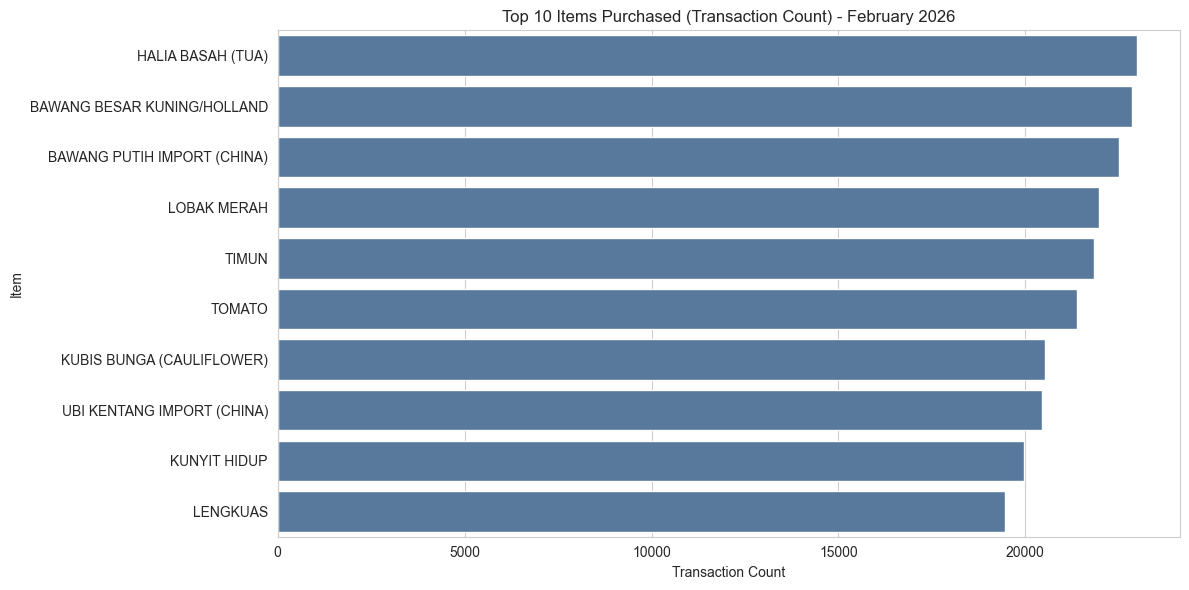

In [ ]:
# Filter to February 2026
feb_2026_df = df.loc[
    (df["date"] >= "2026-02-01") & (df["date"] <= "2026-02-28")
].copy()

# Top 10 items by number of transactions (proxy for purchases)
top_10_items = (
    feb_2026_df["item"]
    .value_counts()
    .head(10)
    .rename_axis("item")
    .reset_index(name="transaction_count")
)

display(top_10_items)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_10_items,
    x="transaction_count",
    y="item",
    order=top_10_items.sort_values(
        "transaction_count", ascending=False)["item"],
    color="#4C78A8"
)
ax.set_title("Top 10 Items Purchased (Transaction Count) - February 2026")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("Item")
plt.tight_layout()
plt.show()

### #2 State-level transaction distribution and trend

1. Bar chart of transaction counts by state.
2. Line chart of daily transaction counts over time for the top 5 states (by total transactions).


,state,transaction_count
0,W.P. Kuala Lumpur,115027
1,Johor,114611
2,Sarawak,101819
3,Perak,100219
4,Pahang,85901
5,Kelantan,80160
6,Selangor,79745
7,Pulau Pinang,71482
8,Sabah,66971
9,Terengganu,58957


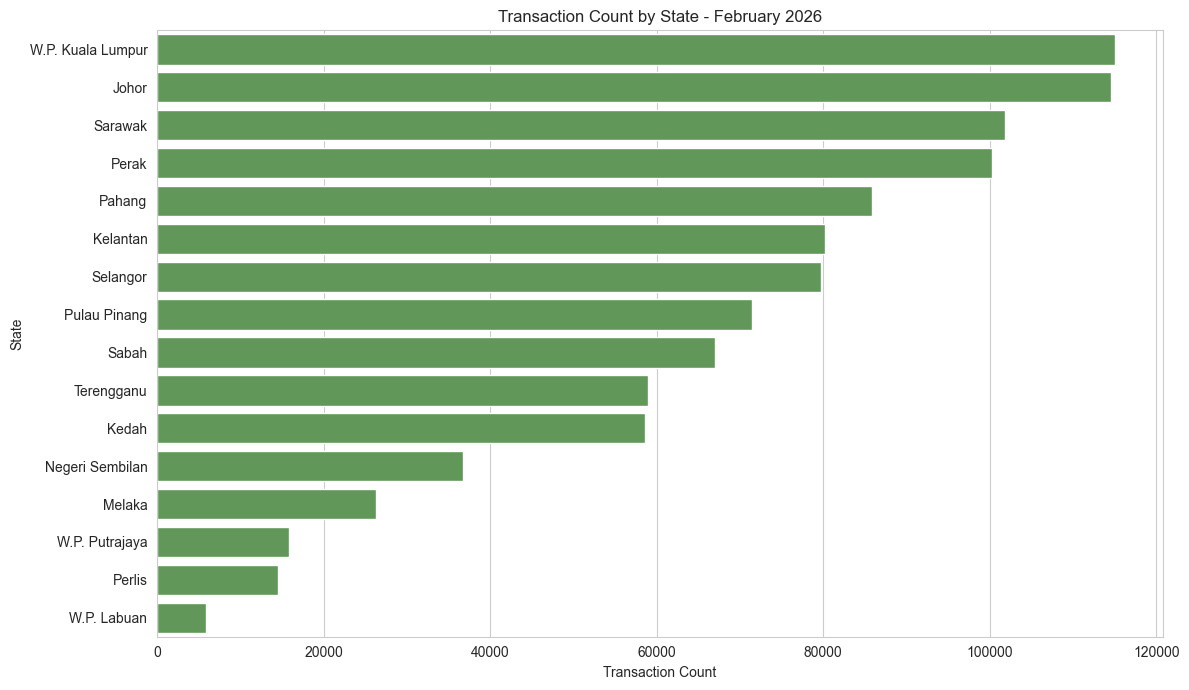

,top_5_states
0,W.P. Kuala Lumpur
1,Johor
2,Sarawak
3,Perak
4,Pahang


,date,state,transaction_count
4,2026-02-03,Johor,3898
9,2026-02-04,Johor,3939
14,2026-02-05,Johor,3884
19,2026-02-06,Johor,3934
24,2026-02-07,Johor,3914
29,2026-02-08,Johor,4277
34,2026-02-09,Johor,18859
39,2026-02-10,Johor,3909
44,2026-02-11,Johor,3996
49,2026-02-12,Johor,19907


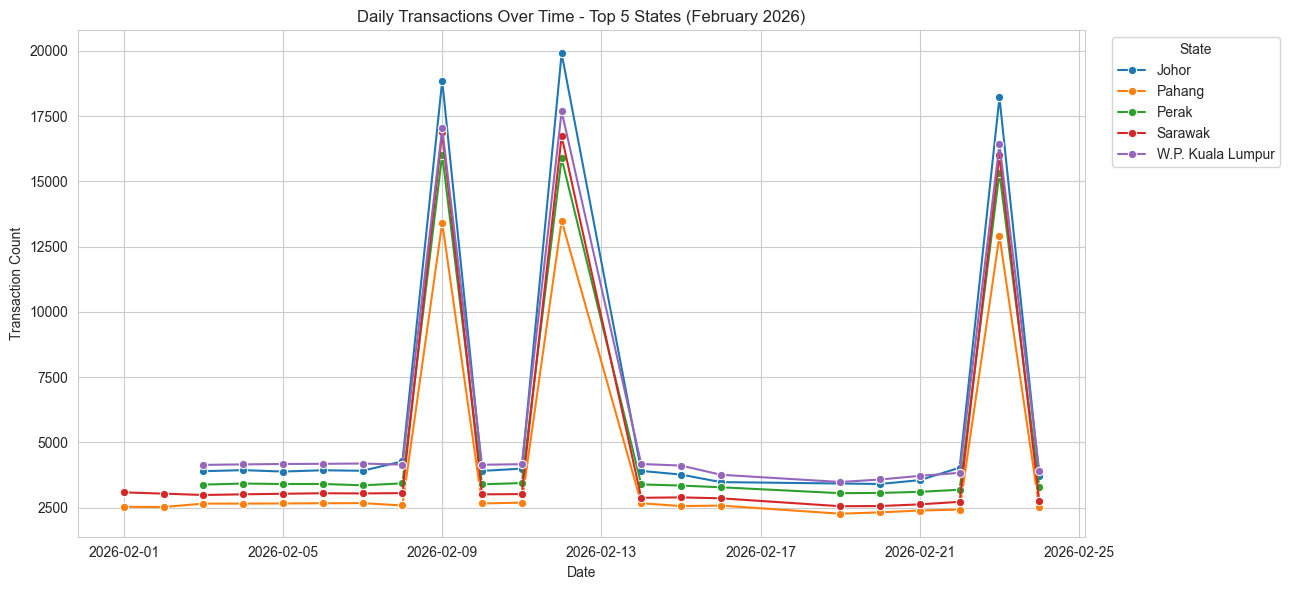

In [ ]:
# Transactions by state (February 2026)
state_counts = (
    feb_2026_df["state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="transaction_count")
)

display(state_counts)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=state_counts,
    x="transaction_count",
    y="state",
    order=state_counts.sort_values(
        "transaction_count", ascending=False)["state"],
    color="#59A14F"
)
ax.set_title("Transaction Count by State - February 2026")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

# Daily transactions over time for top 5 states
top_5_states = state_counts.head(5)["state"].tolist()

daily_top5 = (
    feb_2026_df[feb_2026_df["state"].isin(top_5_states)]
    .groupby(["date", "state"])
    .size()
    .reset_index(name="transaction_count")
    .sort_values(["state", "date"])
)

display(pd.DataFrame({"top_5_states": top_5_states}))
display(daily_top5.head(20))

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=daily_top5,
    x="date",
    y="transaction_count",
    hue="state",
    marker="o"
)
plt.title("Daily Transactions Over Time - Top 5 States (February 2026)")
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### #3 State spending power (sum of price)

We estimate state-level spending power by summing transaction `price` in February 2026, then rank states by total spend.


,rank,state,total_spending
13,1,W.P. Kuala Lumpur,1438446.20
0,2,Johor,1286731.29
10,3,Sarawak,1265470.10
6,4,Perak,1126754.95
5,5,Pahang,940428.60
11,6,Selangor,940368.12
2,7,Kelantan,890650.21
8,8,Pulau Pinang,798201.83
9,9,Sabah,762368.74
1,10,Kedah,645926.71


,top_state_by_total_spending,total_spending
0,W.P. Kuala Lumpur,1438446.2


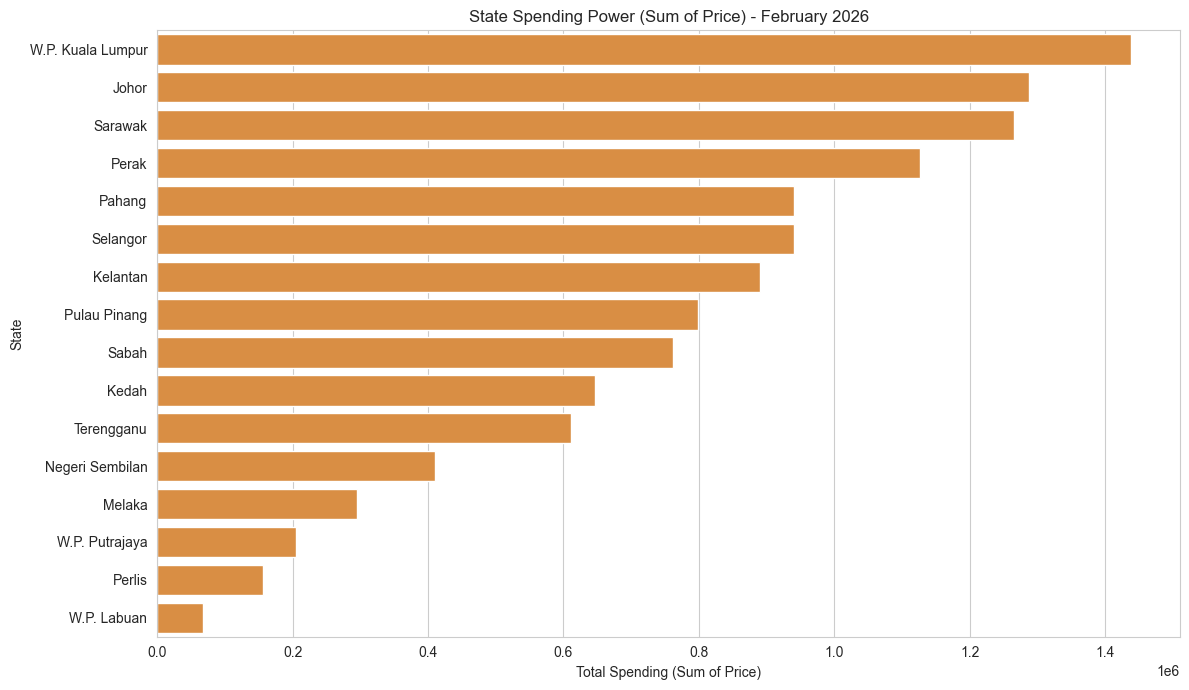

In [4]:
# State spending power by total transaction value (February 2026)
state_spending = (
    feb_2026_df.groupby("state", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "total_spending"})
    .sort_values("total_spending", ascending=False)
)

# Add rank for readability
state_spending["rank"] = range(1, len(state_spending) + 1)
state_spending = state_spending[["rank", "state", "total_spending"]]

display(state_spending)

display(pd.DataFrame([{
    "top_state_by_total_spending": state_spending.iloc[0]["state"],
    "total_spending": state_spending.iloc[0]["total_spending"],
}]))

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=state_spending,
    x="total_spending",
    y="state",
    order=state_spending["state"],
    color="#F28E2B"
)
ax.set_title("State Spending Power (Sum of Price) - February 2026")
ax.set_xlabel("Total Spending (Sum of Price)")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

### #4 Item category exploration

1. Trend of purchases by `item_category` across February 2026.
2. Top 10 item categories by total purchases in February 2026.


,date,item_category,transaction_count
0,2026-02-01,AYAM,443
7,2026-02-02,AYAM,498
14,2026-02-03,AYAM,1061
21,2026-02-04,AYAM,1076
28,2026-02-05,AYAM,1069
35,2026-02-06,AYAM,1069
55,2026-02-07,AYAM,1059
63,2026-02-08,AYAM,1103
87,2026-02-09,AYAM,5135
121,2026-02-10,AYAM,1059


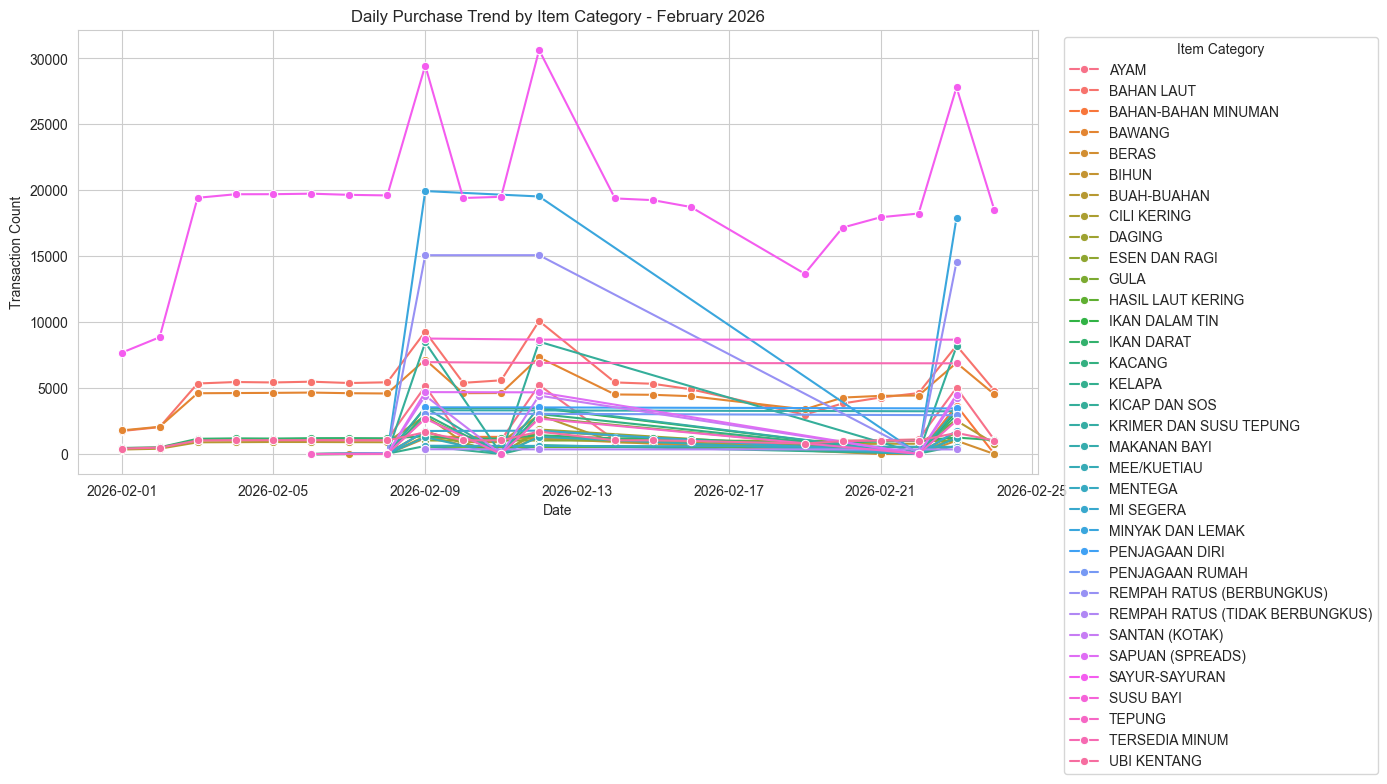

In [ ]:
# Daily trend of purchases by item category (February 2026)
daily_category_trend = (
    feb_2026_df.groupby(["date", "item_category"])
    .size()
    .reset_index(name="transaction_count")
    .sort_values(["item_category", "date"])
)

display(daily_category_trend.head(20))

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=daily_category_trend,
    x="date",
    y="transaction_count",
    hue="item_category",
    marker="o"
)
plt.title("Daily Purchase Trend by Item Category - February 2026")
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.legend(title="Item Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

,item_category,transaction_count
0,SAYUR-SAYURAN,404127
1,BAHAN LAUT,111164
2,BAWANG,96719
3,MINYAK DAN LEMAK,57461
4,REMPAH RATUS (BERBUNGKUS),44875
5,AYAM,33072
6,SUSU BAYI,26116
7,KICAP DAN SOS,25246
8,BUAH-BUAHAN,22758
9,IKAN DARAT,22663


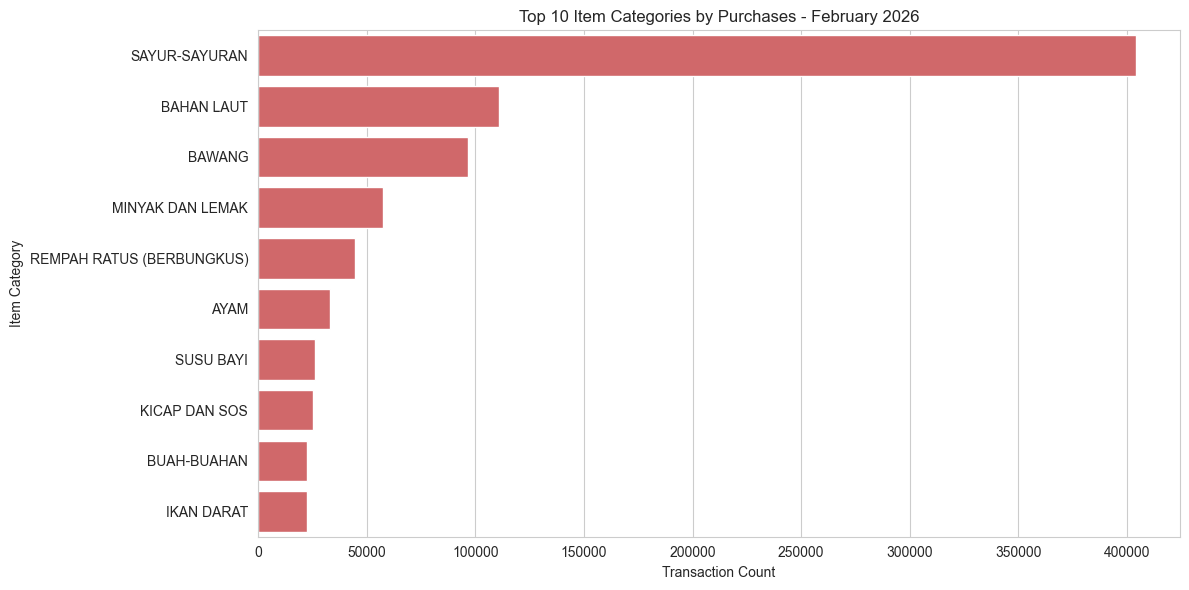

In [ ]:
# Top 10 item categories by total purchases (transaction count) in February 2026
top_10_categories = (
    feb_2026_df["item_category"]
    .value_counts()
    .head(10)
    .rename_axis("item_category")
    .reset_index(name="transaction_count")
)

display(top_10_categories)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_10_categories,
    x="transaction_count",
    y="item_category",
    order=top_10_categories.sort_values("transaction_count", ascending=False)[
        "item_category"],
    color="#E15759"
)
ax.set_title("Top 10 Item Categories by Purchases - February 2026")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("Item Category")
plt.tight_layout()
plt.show()

In [7]:
# Percentage share of each item category out of all purchase records
category_share_df = (
    feb_2026_df["item_category"]
    .value_counts(dropna=False)
    .rename_axis("item_category")
    .reset_index(name="transaction_count")
)
category_share_df["pct_of_all_records"] = (
    category_share_df["transaction_count"] / len(feb_2026_df) * 100
)

# Display full category share table
display(category_share_df)

# Display SAYUR-SAYURAN share specifically
sayur_share_df = category_share_df[
    category_share_df["item_category"].str.upper() == "SAYUR-SAYURAN"
].copy()

display(sayur_share_df)

,item_category,transaction_count,pct_of_all_records
0,SAYUR-SAYURAN,404127,39.137066
1,BAHAN LAUT,111164,10.765509
2,BAWANG,96719,9.366605
3,MINYAK DAN LEMAK,57461,5.564723
4,REMPAH RATUS (BERBUNGKUS),44875,4.345851
5,AYAM,33072,3.202808
6,SUSU BAYI,26116,2.529164
7,KICAP DAN SOS,25246,2.444911
8,BUAH-BUAHAN,22758,2.203964
9,IKAN DARAT,22663,2.194764


,item_category,transaction_count,pct_of_all_records
0,SAYUR-SAYURAN,404127,39.137066


### #5 State-level purchases for `SAYUR-SAYURAN` over time

This section filters to `SAYUR-SAYURAN` and shows:

1. Total purchases by state during February 2026.
2. Daily purchase trend by state from start to end date.


,start_date,end_date,total_sayur_transactions
0,2026-02-01,2026-02-24,404127


,state,transaction_count
0,Johor,44479
13,W.P. Kuala Lumpur,43905
6,Perak,38101
10,Sarawak,36841
5,Pahang,35421
11,Selangor,31917
8,Pulau Pinang,31001
2,Kelantan,30952
12,Terengganu,25862
9,Sabah,24272


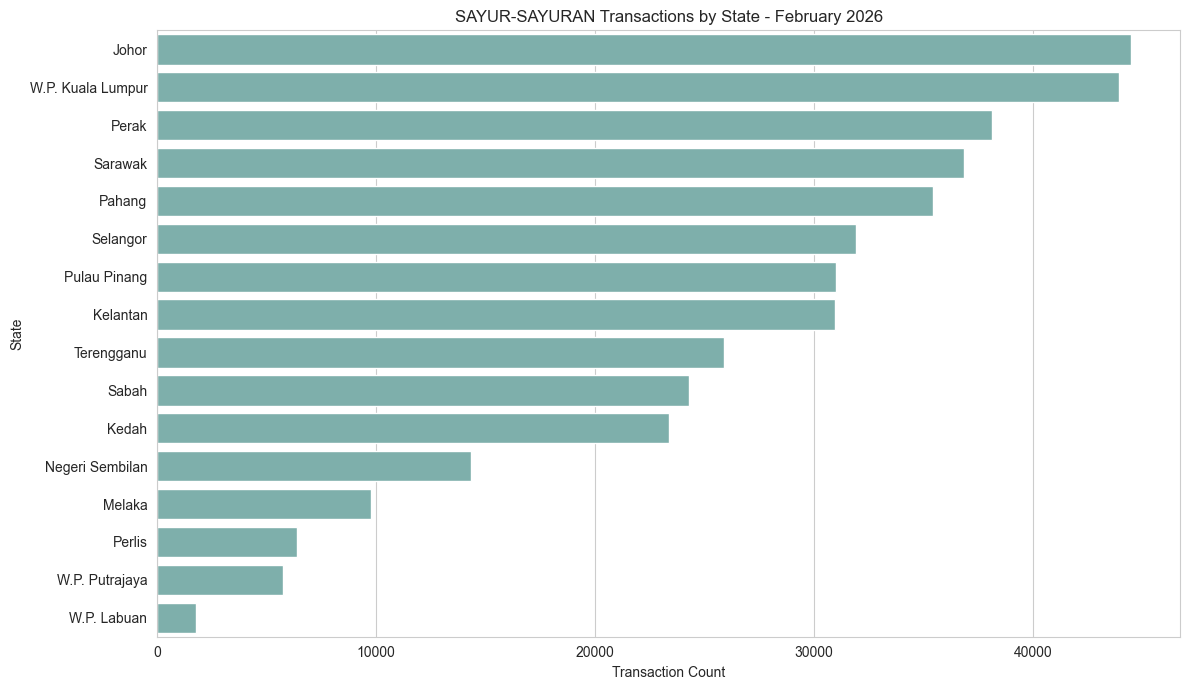

,date,state,transaction_count
15,2026-02-03,Johor,2277
31,2026-02-04,Johor,2276
47,2026-02-05,Johor,2273
63,2026-02-06,Johor,2293
79,2026-02-07,Johor,2276
95,2026-02-08,Johor,2291
111,2026-02-09,Johor,3662
127,2026-02-10,Johor,2261
143,2026-02-11,Johor,2289
159,2026-02-12,Johor,3978


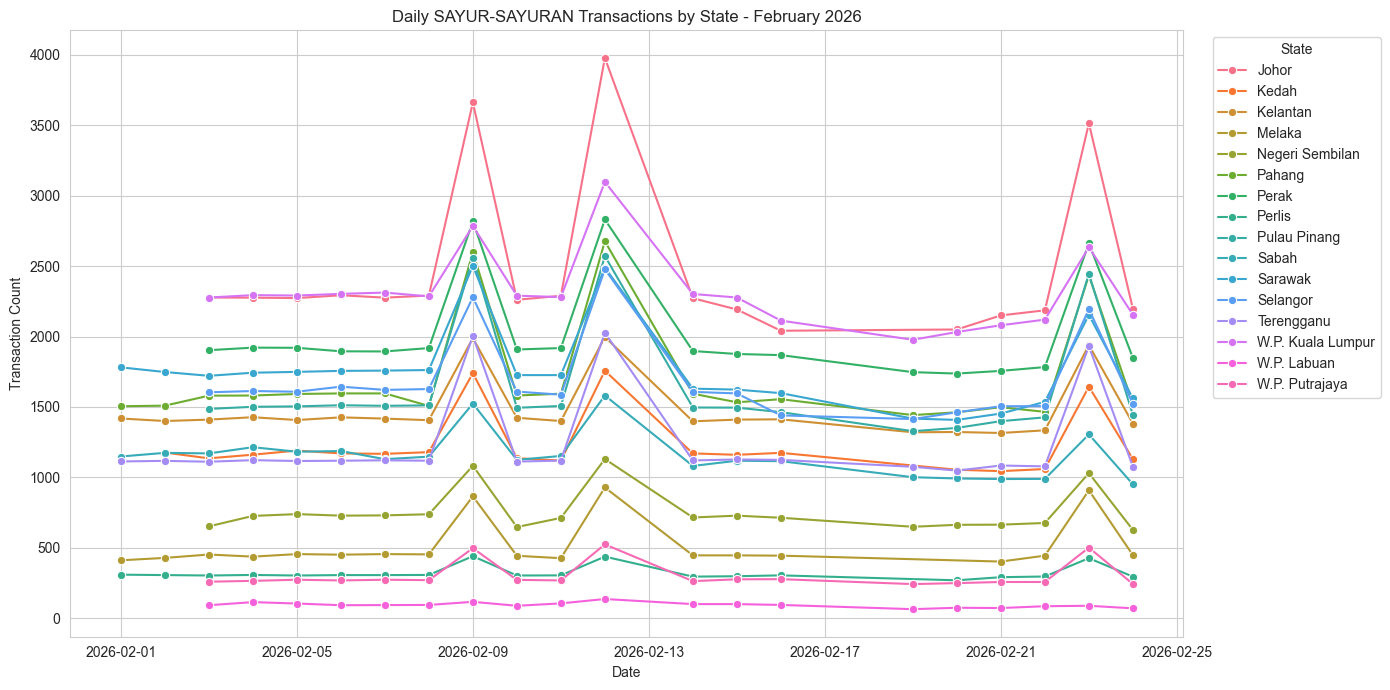

In [8]:
# Filter SAYUR-SAYURAN transactions
sayur_df = feb_2026_df.loc[
    feb_2026_df["item_category"].str.upper() == "SAYUR-SAYURAN"
].copy()

# Summary: total SAYUR-SAYURAN purchases by state
sayur_state_summary = (
    sayur_df.groupby("state", as_index=False)
    .size()
    .rename(columns={"size": "transaction_count"})
    .sort_values("transaction_count", ascending=False)
)

display(pd.DataFrame([{
    "start_date": sayur_df["date"].min(),
    "end_date": sayur_df["date"].max(),
    "total_sayur_transactions": len(sayur_df),
}]))
display(sayur_state_summary)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=sayur_state_summary,
    x="transaction_count",
    y="state",
    order=sayur_state_summary["state"],
    color="#76B7B2"
)
ax.set_title("SAYUR-SAYURAN Transactions by State - February 2026")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

# Daily trend by state for SAYUR-SAYURAN
sayur_daily_state = (
    sayur_df.groupby(["date", "state"], as_index=False)
    .size()
    .rename(columns={"size": "transaction_count"})
    .sort_values(["state", "date"])
)

display(sayur_daily_state.head(30))

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=sayur_daily_state,
    x="date",
    y="transaction_count",
    hue="state",
    marker="o"
)
plt.title("Daily SAYUR-SAYURAN Transactions by State - February 2026")
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### #6 `SAYUR-SAYURAN` price trend by state (daily mean)

This section compares vegetable price levels across states by:

1. Calculating daily mean `price` for `SAYUR-SAYURAN` per state.
2. Plotting daily mean price trends by state.
3. Summarizing each state's overall mean and volatility (`std`) over February 2026.


,rows_used,rows_excluded_no_price_per_kg
0,404127,0


,date,state,mean_price_per_kg
15,2026-02-03,Johor,8.803623
31,2026-02-04,Johor,8.696112
47,2026-02-05,Johor,8.617457
63,2026-02-06,Johor,8.520318
79,2026-02-07,Johor,8.458506
95,2026-02-08,Johor,8.489952
111,2026-02-09,Johor,9.454508
127,2026-02-10,Johor,8.453941
143,2026-02-11,Johor,8.458973
159,2026-02-12,Johor,9.436159


,state,mean_price_per_kg,std_price_per_kg,median_price_per_kg,observations
10,Sarawak,11.167308,9.155424,8.90,36841
15,W.P. Putrajaya,10.037665,6.375496,8.90,5734
13,W.P. Kuala Lumpur,9.809846,8.410487,7.99,43905
14,W.P. Labuan,9.736502,4.656240,8.90,1781
7,Perlis,9.507001,5.847092,8.00,6405
9,Sabah,9.283364,7.836762,7.90,24272
11,Selangor,8.780360,5.712441,7.89,31917
12,Terengganu,8.732138,5.060985,7.99,25862
0,Johor,8.647117,5.759202,7.58,44479
2,Kelantan,8.634115,5.456425,7.88,30952


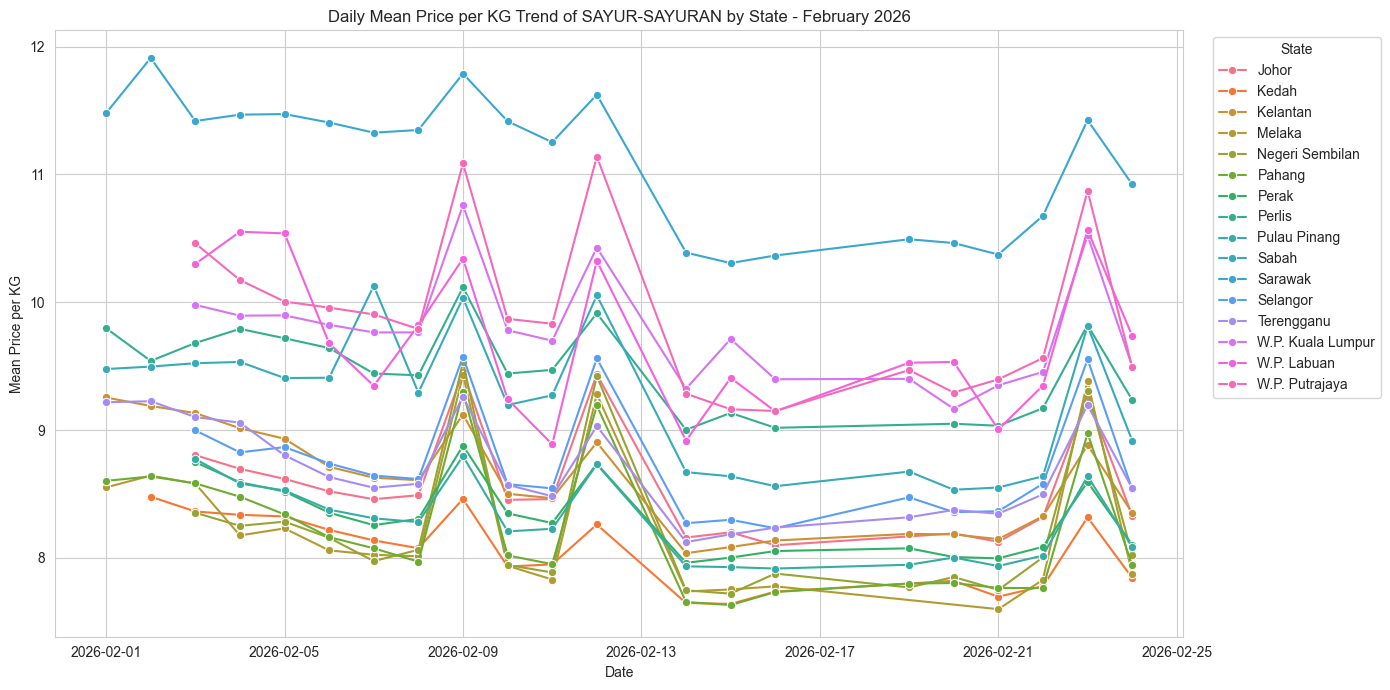

In [ ]:
# Daily mean price_per_kg of SAYUR-SAYURAN by state
sayur_mass_df = sayur_df.loc[sayur_df["price_per_kg"].notna()].copy()

sayur_daily_price_state = (
    sayur_mass_df.groupby(["date", "state"], as_index=False)["price_per_kg"]
    .mean()
    .rename(columns={"price_per_kg": "mean_price_per_kg"})
    .sort_values(["state", "date"])
)

display(pd.DataFrame([{"rows_used": len(
    sayur_mass_df), "rows_excluded_no_price_per_kg": len(sayur_df) - len(sayur_mass_df)}]))
display(sayur_daily_price_state.head(30))

# Overall state-level summary for comparison
sayur_price_state_summary = (
    sayur_mass_df.groupby("state", as_index=False)["price_per_kg"]
    .agg(mean_price_per_kg="mean", std_price_per_kg="std", median_price_per_kg="median", observations="count")
    .sort_values("mean_price_per_kg", ascending=False)
)

display(sayur_price_state_summary)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=sayur_daily_price_state,
    x="date",
    y="mean_price_per_kg",
    hue="state",
    marker="o"
)
plt.title("Daily Mean Price per KG Trend of SAYUR-SAYURAN by State - February 2026")
plt.xlabel("Date")
plt.ylabel("Mean Price per KG")
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### #7 Daily mean `price_per_kg` trend for `BAHAN LAUT` and `BAWANG`

Using the same approach as `SAYUR-SAYURAN`, this section compares state-level daily mean `price_per_kg` for:

- `BAHAN LAUT`
- `BAWANG`


,matched_categories
0,BAHAN LAUT
1,BAWANG


,item_category,mean_price_per_kg,std_price_per_kg,observations
0,BAHAN LAUT,23.945357,13.228979,111164
1,BAWANG,6.462473,4.132218,96719


,item_category,rows_used
0,BAHAN LAUT,111164


,state,mean_price_per_kg,std_price_per_kg,observations
13,W.P. Kuala Lumpur,28.571341,15.927817,14687
15,W.P. Putrajaya,28.435004,14.613635,2280
11,Selangor,25.029108,16.900084,11183
8,Pulau Pinang,24.483885,12.558501,7656
5,Pahang,23.441741,11.770114,9428
1,Kedah,23.396143,11.363732,6039
12,Terengganu,23.396037,11.393774,3793
4,Negeri Sembilan,23.391815,11.779054,4660
3,Melaka,23.262828,11.866263,3469
6,Perak,23.117162,11.822472,12229


,date,state,mean_price_per_kg
15,2026-02-03,Johor,22.455524
31,2026-02-04,Johor,22.005029
47,2026-02-05,Johor,22.179424
63,2026-02-06,Johor,22.124687
79,2026-02-07,Johor,22.105865
95,2026-02-08,Johor,23.064319
111,2026-02-09,Johor,25.631817
127,2026-02-10,Johor,21.565015
143,2026-02-11,Johor,21.563727
159,2026-02-12,Johor,26.397676


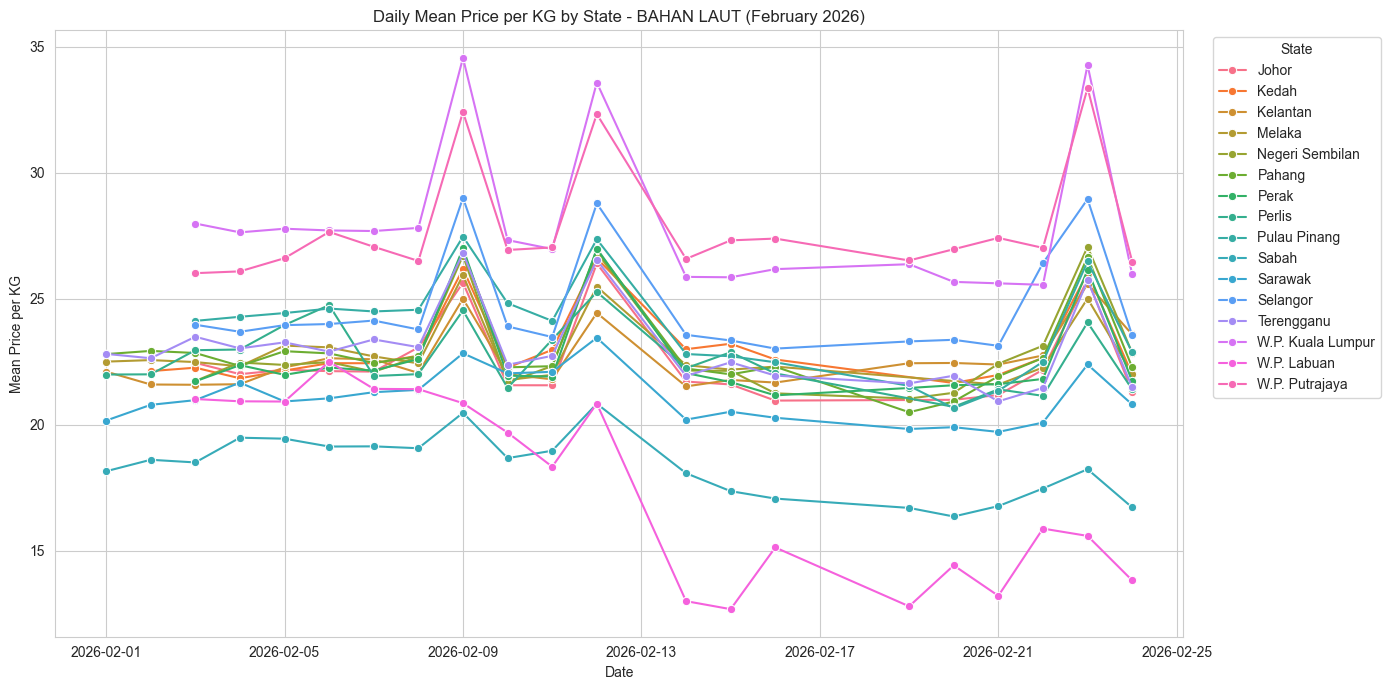

,item_category,rows_used
0,BAWANG,96719


,state,mean_price_per_kg,std_price_per_kg,observations
14,W.P. Labuan,7.482991,4.527680,692
8,Pulau Pinang,7.074744,4.340916,6921
9,Sabah,7.062729,3.531777,7447
10,Sarawak,7.022227,4.412410,11064
4,Negeri Sembilan,6.826925,4.255748,3389
13,W.P. Kuala Lumpur,6.759505,4.321044,11261
6,Perak,6.624645,4.287928,9546
1,Kedah,6.612623,4.557411,5695
11,Selangor,6.510929,4.205979,7288
3,Melaka,6.468673,3.899611,2456


,date,state,mean_price_per_kg
15,2026-02-03,Johor,6.224274
31,2026-02-04,Johor,6.349940
47,2026-02-05,Johor,6.305498
63,2026-02-06,Johor,6.266680
79,2026-02-07,Johor,6.266811
95,2026-02-08,Johor,6.192393
111,2026-02-09,Johor,6.656654
127,2026-02-10,Johor,6.382378
143,2026-02-11,Johor,6.456876
159,2026-02-12,Johor,6.994422


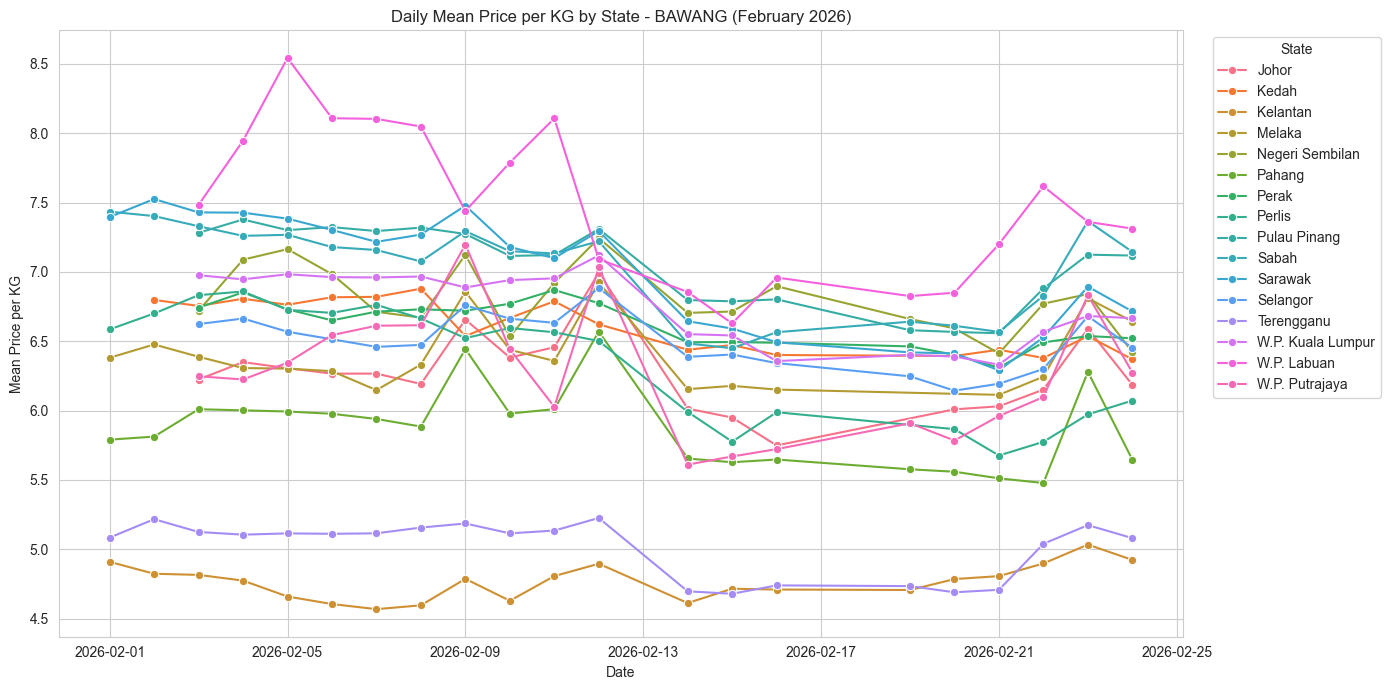

In [ ]:
# Daily mean price_per_kg trend by state for BAHAN LAUT and BAWANG
focus_categories = ["BAHAN LAUT", "BAWANG"]

# Flexible matching so minor naming differences still resolve
focus_mask = feb_2026_df["item_category"].str.upper().str.contains(
    "BAHAN.*LAUT|BAWANG", regex=True, na=False)
focus_df = feb_2026_df.loc[focus_mask &
                           feb_2026_df["price_per_kg"].notna()].copy()

display(pd.DataFrame({"matched_categories": sorted(
    focus_df["item_category"].dropna().unique())}))

focus_summary = (
    focus_df.groupby("item_category", as_index=False)["price_per_kg"]
    .agg(mean_price_per_kg="mean", std_price_per_kg="std", observations="count")
    .sort_values("observations", ascending=False)
)

display(focus_summary)

for category in sorted(focus_df["item_category"].dropna().unique()):
    cat_df = focus_df.loc[focus_df["item_category"] == category].copy()

    daily_cat_state = (
        cat_df.groupby(["date", "state"], as_index=False)["price_per_kg"]
        .mean()
        .rename(columns={"price_per_kg": "mean_price_per_kg"})
        .sort_values(["state", "date"])
    )

    state_summary = (
        cat_df.groupby("state", as_index=False)["price_per_kg"]
        .agg(mean_price_per_kg="mean", std_price_per_kg="std", observations="count")
        .sort_values("mean_price_per_kg", ascending=False)
    )

    display(pd.DataFrame(
        [{"item_category": category, "rows_used": len(cat_df)}]))
    display(state_summary)
    display(daily_cat_state.head(20))

    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=daily_cat_state,
        x="date",
        y="mean_price_per_kg",
        hue="state",
        marker="o"
    )
    plt.title(f"Daily Mean Price per KG by State - {category} (February 2026)")
    plt.xlabel("Date")
    plt.ylabel("Mean Price per KG")
    plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### Seems like seafood is expensive in KL and veggies are expensive in Sarawak
